# Clustering

Every model so far has been handed the right answer. But picture being a buyer in front of a rail of unlabelled samples - no tags, no categories, just pieces - and having to find the natural families hiding in there. That is clustering, and it is such a real part of actually working with clothes. Here I let K-Means group the garments entirely on its own, and then I sneak a look at the labels I had hidden, to see how close its instincts came to ours.

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
np.random.seed(SEED)
DATA, RESULTS = Path("data"), Path("results")
RESULTS.mkdir(exist_ok=True)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

npz = np.load(DATA / "fashion_mnist_subset.npz", allow_pickle=True)
images = npz["X_train"]
X = images.reshape(len(images), -1).astype(float) / 255.0
y_true = npz["y_train"]
class_names = list(npz["class_names"])

# PCA preprocessing 
from sklearn.decomposition import PCA
Xp = PCA(n_components=50, random_state=SEED).fit_transform(X)
print("clustering features:", Xp.shape)

clustering features: (6000, 50)


## 1. K-Means from scratch

K-Means partitions points into $K$ clusters to minimise the within-cluster sum of squares (also called inertia):

$$
J = \sum_{k=1}^{K} \sum_{x \in C_k} \lVert x - \mu_k \rVert^2, \qquad \mu_k = \frac{1}{|C_k|}\sum_{x \in C_k} x.
$$

Lloyd's algorithm alternates two steps until the assignments stop changing:
1. Assign each point to its nearest centroid.
2. Update each centroid to the mean of its assigned points.

This is coordinate descent on $J$, so $J$ never increases - but it only finds a local optimum, so we use k-means++ seeding (spread the initial centroids out) and keep the best of several restarts.

In [2]:
def _sq_dists(X, C):
    '''Squared Euclidean distances between every row of X and every centroid in C.'''
    return (X**2).sum(1)[:, None] - 2 * X @ C.T + (C**2).sum(1)[None, :]

class KMeans:
    '''K-Means with k-means++ initialisation and multiple restarts.'''
    def __init__(self, n_clusters, n_init=6, max_iter=100, tol=1e-4, seed=SEED):
        self.k, self.n_init, self.max_iter, self.tol, self.seed = \
            n_clusters, n_init, max_iter, tol, seed

    def _kpp_init(self, X, rng):
        centers = [X[rng.integers(len(X))]]
        for _ in range(1, self.k):
            # clip tiny negative values that floating-point can produce in _sq_dists
            d2 = np.maximum(_sq_dists(X, np.array(centers)).min(axis=1), 0.0)
            total = d2.sum()
            probs = d2 / total if total > 0 else np.full(len(X), 1.0 / len(X))
            centers.append(X[rng.choice(len(X), p=probs)])
        return np.array(centers)

    def _one_run(self, X, rng):
        C = self._kpp_init(X, rng)
        for _ in range(self.max_iter):
            labels = _sq_dists(X, C).argmin(axis=1)
            newC = np.array([X[labels == j].mean(axis=0) if np.any(labels == j) else C[j]
                             for j in range(self.k)])
            shift = np.linalg.norm(newC - C)
            C = newC
            if shift < self.tol:
                break
        inertia = float(np.maximum(_sq_dists(X, C)[np.arange(len(X)), labels], 0.0).sum())
        return labels, C, inertia

    def fit(self, X):
        X = np.asarray(X, float)
        best = None
        for i in range(self.n_init):
            res = self._one_run(X, np.random.default_rng(self.seed + i))
            if best is None or res[2] < best[2]:
                best = res
        self.labels_, self.cluster_centers_, self.inertia_ = best
        return self

    def predict(self, X):
        return _sq_dists(np.asarray(X, float), self.cluster_centers_).argmin(axis=1)

km = KMeans(n_clusters=10).fit(Xp)
print(f"our inertia (k=10): {km.inertia_:.1f}")

from sklearn.cluster import KMeans as SkKMeans
sk = SkKMeans(n_clusters=10, n_init=6, random_state=SEED).fit(Xp)
print(f"scikit-learn inertia: {sk.inertia_:.1f}  (within a few % is expected)")

our inertia (k=10): 136230.7


scikit-learn inertia: 136801.0  (within a few % is expected)


## 2. How many clusters? The elbow method

Inertia always drops as $K$ grows (more centroids fit tighter), so we look for the elbow - the $K$ after which extra clusters buy little. We sweep $K = 2 \dots 10$.

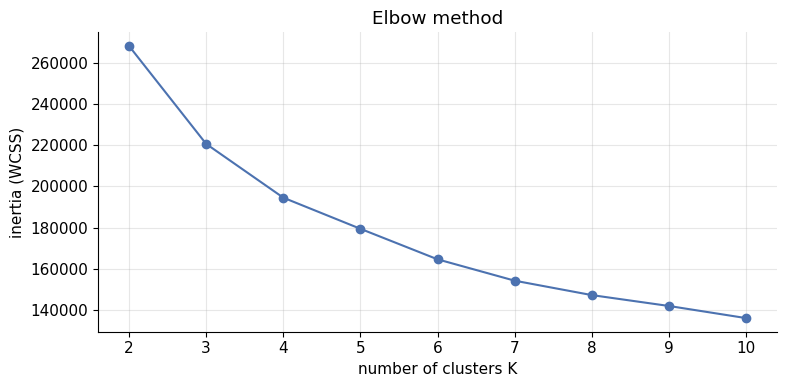

In [3]:
Ks = range(2, 11)
inertias = [KMeans(n_clusters=k, n_init=4).fit(Xp).inertia_ for k in Ks]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(Ks), inertias, "o-", color="#4C72B0")
ax.set_title("Elbow method"); ax.set_xlabel("number of clusters K"); ax.set_ylabel("inertia (WCSS)")
plt.tight_layout(); plt.show()